In [ ]:
import pandas as pd 
import numpy as np 
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

#Agglomerative Clustering is a hierarchical clustering method that builds a hierarchy of clusters by iteratively merging or splitting them based on their similarity. It starts with each data point as its own cluster and then merges the closest clusters until a stopping criterion is met, such as a specified number of clusters or a distance threshold. The result is a dendrogram, which is a tree-like diagram that shows the relationships between the clusters. Agglomerative Clustering can be used for various applications, including image segmentation, customer segmentation, and gene expression analysis.

In [6]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# Generate high-dimensional blobs
X, y = make_blobs(
    n_samples=500,
    n_features=20,
    centers=5,
    cluster_std=2.0,
    random_state=42
)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 3D using PCA
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

# Create dataframe
df = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df['Cluster'] = y.astype(str)

# 3D Plotly scatter
fig = px.scatter_3d(
    df,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='High-Dimensional Blobs (PCA → 3D)',
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

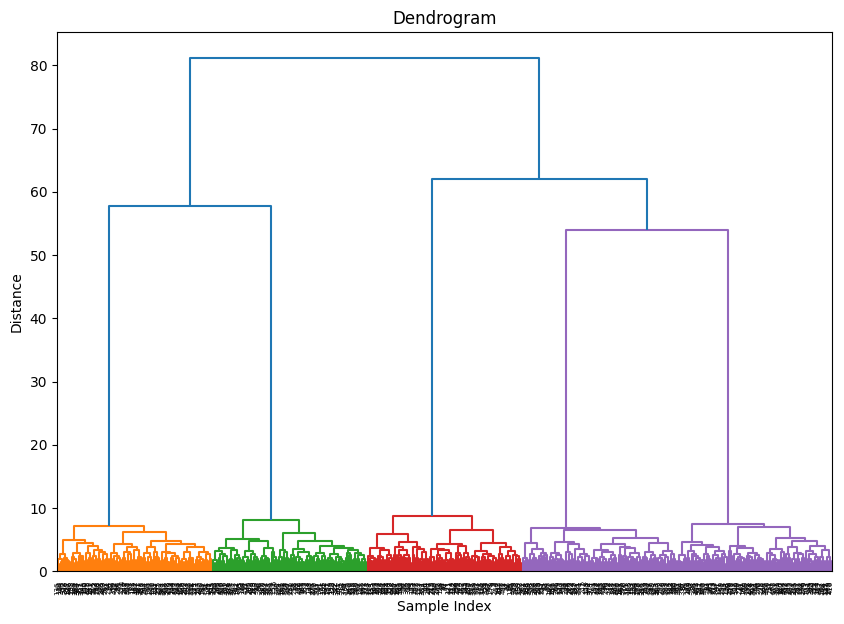

In [7]:
#We will plot an endogram using the SciPy library. 
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
dend = dendrogram(linkage(X_scaled, method='ward'))
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

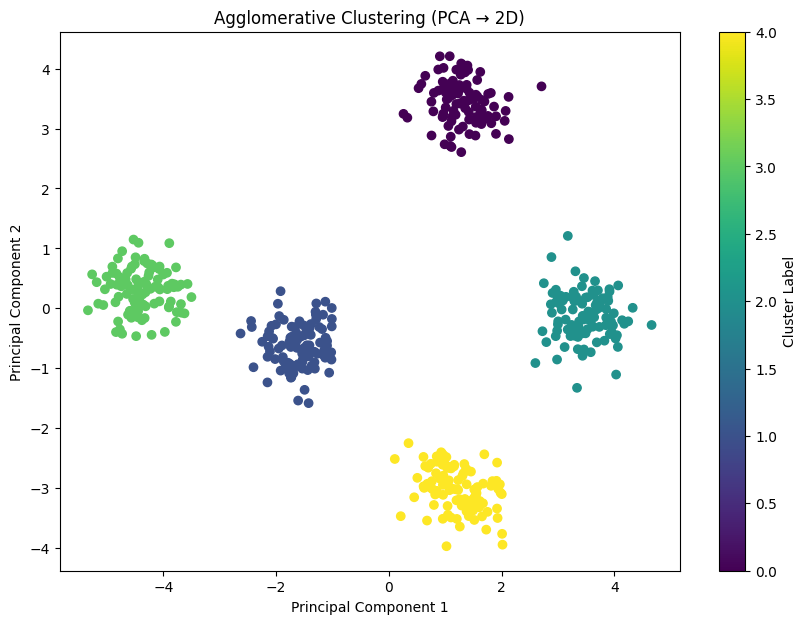

In [8]:
#from the above dendrogram, we can see that there are 5 clusters in the data. We will use the AgglomerativeClustering class from the sklearn library to perform agglomerative clustering on the data. We will set the number of clusters to 5 and the linkage method to 'ward'.

agglomerative = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_pred = agglomerative.fit_predict(X_scaled)
#We will plot the clusters using the PCA components. We will use the first two principal components to plot the clusters in a 2D space.

plt.figure(figsize=(10, 7))
plt.scatter(X_3d[:, 0], X_3d[:, 1], c=y_pred, cmap='viridis')
plt.title("Agglomerative Clustering (PCA → 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster Label')
plt.show()


In [ ]:
#we will further use this on the coutry data. We will use the AgglomerativeClustering class from the sklearn library to perform agglomerative clustering on the country data